In [ ]:
### autoreload
%reload_ext autoreload
%autoreload 2

# custom
from calcification.analysis import analysis, analysis_utils, meta_regression
from calcification.utils import config
from calcification.plotting import analysis as analysis_plot
from calcification.plotting import (
    plot_utils,
    climatology,
    plot_config,
    data_exploration,
)
from calcification.processing import (
    climatology as climatology_processing,
    process,
)
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from app import metafor

# custom plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import seaborn as sns

from matplotlib.cm import get_cmap
from matplotlib.colors import to_hex
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

effect_type = "st_relative_calcification"


In [ ]:
# load extracted data (with effect sizes)
data_df = process.process_extracted_calcification_data(
    fp=config.data_dir / "Orlando_data.xlsx",
)
# drop row with nans. TODO: find where the nan in var comes from
data_df = data_df.dropna(
    subset=["st_relative_calcification", "st_relative_calcification_var"]
)
# N.B. standardisation makes no difference on significance, coefficients etc.
data_df["dt_s"] = data_df["delta_t"] / np.std(data_df["delta_t"])
data_df["dp_s"] = data_df["delta_ph"] / np.std(data_df["delta_ph"])
# order by number of samples in core_grouping
data_df = data_df.sort_values(
    "core_grouping",
    key=lambda x: x.map(lambda y: len(data_df[data_df["core_grouping"] == y])),
    ascending=False,
)

In [ ]:
local_climatology_df, global_future_anomaly_df, global_anomaly_df = (
    process.process_climatology_data(
        data_df,
        config.climatology_data_dir / "ph_scenarios_output_table_site_locations.csv",
        config.climatology_data_dir / "sst_scenarios_output_table_site_locations.csv",
        config.resources_dir / "locations.yaml",
    )
)
# extrapolate to end of century
global_anomaly_df = climatology_processing.extrapolate_df(global_anomaly_df)


In [ ]:
max_t = global_anomaly_df.anomaly_value_sst.max()
min_ph = global_anomaly_df.anomaly_value_ph.min()

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].hist(data_df.delta_t, bins=25)
ax[1].hist(data_df.delta_ph, bins=25)
ax[0].vlines(max_t, ax[0].get_ylim()[1], 0, color="red", label=f"max sst: {max_t:.5f}")
ax[1].vlines(min_ph, ax[1].get_ylim()[1], 0, color="red", label=f"min ph: {min_ph:.5f}")
for a in ax:
    a.set_xlabel("Temperature/pH anomaly")
    a.set_ylabel("Count")
    a.set_ylim(0, a.get_ylim()[1])
    a.legend()

# limit data_df
clim_data_df = data_df[
    (data_df.delta_t < max_t)
    & (data_df.delta_t >= -0.5)
    & (data_df.delta_ph > min_ph)
    & (data_df.delta_ph <= 0.08)
]
print(max_t)
print(min_ph)
print(clim_data_df.shape)
print(clim_data_df.original_doi.nunique())
print(data_df.original_doi.nunique())

In [ ]:
set(data_df.original_doi).difference(set(clim_data_df.original_doi))

In [ ]:
data_df[data_df.original_doi == "10.1007/s00425-013-1982-1"][["delta_t", "delta_ph"]]

In [ ]:
# for each core grouping, plot a scatter plot of st_relative_calcification vs delta_t and one vs delta_ph
fig, axes = plt.subplots(
    data_df["core_grouping"].nunique(),
    2,
    figsize=(12, 14),
    sharey=True,
    # sharex=True,
    dpi=150,
)

# Add whitespace between columns
plt.subplots_adjust(wspace=0.3)

yaxis_limits = (-250, 250)

# Store scatter plot objects for color bars
scatter_objects = []

for cg_index, cg in enumerate(data_df["core_grouping"].unique()):
    cg_ax = axes[cg_index, :]
    cg_df = data_df[data_df["core_grouping"] == cg]

    # Right column: delta_t vs st_relative_calcification, colored by delta_ph
    scatter_right = cg_ax[1].scatter(
        cg_df["delta_t"],
        cg_df["st_relative_calcification"],
        c=cg_df["delta_ph"],
        s=200 * 1 / np.sqrt(cg_df["st_relative_calcification_var"]),
        alpha=0.5,
        edgecolor="black",
        linewidth=0.5,
        vmin=data_df["delta_ph"].min(),
        vmax=data_df["delta_ph"].max(),
    )

    # Left column: delta_ph vs st_relative_calcification, colored by delta_t
    scatter_left = cg_ax[0].scatter(
        cg_df["delta_ph"],
        cg_df["st_relative_calcification"],
        c=cg_df["delta_t"],
        s=200 * 1 / np.sqrt(cg_df["st_relative_calcification_var"]),
        alpha=0.5,
        edgecolor="black",
        linewidth=0.5,
        vmin=data_df["delta_t"].min(),
        vmax=data_df["delta_t"].max(),
    )

    # Store scatter objects for color bars (only need one per column)
    if cg_index == 0:
        scatter_objects = [scatter_left, scatter_right]

    for i, a in enumerate(cg_ax.flatten()):
        a.set_ylim(yaxis_limits)
        a.vlines(0, yaxis_limits[0], yaxis_limits[1], color="darkgray", linestyle="--")
        a.hlines(0, -1, 6, color="darkgray", linestyle="--")
        if i == 1:
            if cg_index == data_df["core_grouping"].nunique() - 1:
                a.set_xlabel("Temperature anomaly ($^\\circ$C)")
            a.set_xlim(-1, 6)
            a.axvspan(
                max_t,
                10,
                color="gray",
                alpha=0.4,
            )
            a.text(
                0.98,
                0.98,
                f"# of samples = {len(cg_df)}\n# of studies = {cg_df['original_doi'].nunique()}",
                ha="right",
                va="top",
                transform=a.transAxes,
                fontsize=18,
            )
        else:
            if cg_index == data_df["core_grouping"].nunique() - 1:
                a.set_xlabel("pH anomaly (Total scale)")
            a.text(
                0.02,
                0.98,
                cg,
                ha="left",
                va="top",
                transform=a.transAxes,
                fontsize=18,
            )
            a.axvspan(
                -10,
                min_ph,
                color="gray",
                alpha=0.4,
            )
            a.set_xlim(-1, 0.1)


# Add horizontal color bars at the bottom of each column
# Create color bar for left column (delta_t colors)
cbar_left = fig.colorbar(
    scatter_objects[0],
    ax=axes[:, 0],
    orientation="horizontal",
    shrink=0.8,
    pad=0.15,
    label="Temperature anomaly (°C)",
    anchor=(0.5, -1.6),
)

# Create color bar for right column (delta_ph colors)
cbar_right = fig.colorbar(
    scatter_objects[1],
    ax=axes[:, 1],
    orientation="horizontal",
    shrink=0.8,
    pad=0.5,
    label="pH anomaly (Total scale)",
    anchor=(0.5, -1.6),
)

# add single legend to bottom of figure labelling the shaded region as outside reasonable forecasted climatologies
shaded_patch = mpatches.Patch(
    color="gray",
    alpha=0.4,
    label="Experimental treatments beyond reasonable forecasted climatologies",
)

# Add the legend to the bottom of the figure, centered
fig.legend(
    handles=[shaded_patch],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=1,
    fontsize=16,
    frameon=False,
)


# Add a single y-axis label vertically centered on the figure
fig.text(
    -0.03,
    0.5,
    r"Relative calcification rate $\left(100 \times \frac{\mathrm{rate_{treatment}} - \mathrm{rate_{control}}}{\mathrm{rate_{control}}}\right)$",
    va="center",
    rotation="vertical",
    fontsize=18,
)


plt.tight_layout()
# plt.show()


In [ ]:
working_df.doi.nunique()


In [ ]:
working_df = clim_data_df.copy()

In [ ]:
# format for burning embers: add core_grouping
be_df = pd.DataFrame()
het_df = pd.DataFrame()

models_dict = {}
for cg in tqdm(working_df["core_grouping"].unique()):
    cg_df = working_df[working_df["core_grouping"] == cg].copy()
    cg_model = metafor.MetaforModel(
        cg_df,
        effect_type=effect_type,
        treatment=["phtot", "temp", "temp_phtot"],
        formula=f"{effect_type} ~ delta_t + delta_ph - 1",
        verbose=False,
    ).fit_model()

    models_dict[cg] = cg_model  # get model instance for debugging
    # add model metadata to dataframe
    cg_het_df = cg_model.get_heterogeneity_dataframe()
    cg_het_df["core_grouping"] = cg
    model_surface, meshgrids = cg_model.predict_nd_surface_from_model(
        moderator_names=["delta_t", "delta_ph"],
        moderator_values=[
            np.linspace(0, max_t, 1000),
            np.linspace(min_ph, 0, 1000),
        ],
    )
    cg_climatology = global_anomaly_df.copy()
    cg_climatology.loc[:, "core_grouping"] = cg
    for k in model_surface.keys():
        cg_climatology.loc[:, k] = cg_climatology.apply(
            lambda row: analysis_utils.get_value_from_surface(
                model_surface[k],
                meshgrids,
                row["anomaly_value_sst"],
                row["anomaly_value_ph"],
            ),
            axis=1,
        )
    # extrapolate df and climatology before concatenating

    het_df = pd.concat([het_df, cg_het_df])
    # construct prediction df by tiling test dataframe with a filled core_grouping column
    be_df = pd.concat([be_df, cg_climatology], axis=0)


In [ ]:
m = metafor.MetaforModel(
    clim_data_df[clim_data_df.core_grouping == "Coral"],
    effect_type=effect_type,
    treatment=["phtot", "temp", "temp_phtot"],
    formula=f"{effect_type} ~ delta_t + delta_ph - 1",
    verbose=False,
).fit_model()
m.view_model_summary()

In [ ]:
m.get_coefficients_dataframe()


In [ ]:
m.model_dict["fit.stats"]["REML"]["AICc"]

In [ ]:
# plot bar plot of aic

In [ ]:
# for each core grouping, fit a number of models and return the AICc for each

models = [
    f"{effect_type} ~ delta_t + delta_ph - 1",  # 1
    f"{effect_type} ~ delta_t * delta_ph - 1",  # 2
    f"{effect_type} ~ delta_t + delta_ph + I(delta_t^2) - 1",  # 3
    f"{effect_type} ~ delta_t + delta_ph + I(delta_t^2) + I(delta_ph^2) - 1",  # 4
    f"{effect_type} ~ delta_t + delta_ph + I(delta_t^2) + I(delta_ph^2) + delta_t * delta_ph - 1",  # 5
]
results = {}

for model_i, model in tqdm(enumerate(models), total=len(models), desc="Testing models"):
    results[model_i] = {}
    for cg in tqdm(
        working_df["core_grouping"].unique(),
        total=len(working_df["core_grouping"].unique()),
        desc="Core groupings",
    ):
        results[model_i][cg] = {}
        cg_df = working_df[working_df["core_grouping"] == cg]
        m = metafor.MetaforModel(
            cg_df,
            effect_type=effect_type,
            treatment=["phtot", "temp", "temp_phtot"],
            formula=model,
            verbose=False,
        ).fit_model()
        results[model_i][cg]["model"] = m
        results[model_i][cg]["AICc"] = m.model_dict["fit.stats"]["REML"]["AICc"]


In [ ]:
# Plot bar plots of deltaAICc, deltaBIC, and deltaQE (all relative to best model per core_grouping)

import matplotlib.pyplot as plt
import numpy as np

core_groupings = list(working_df["core_grouping"].unique())
model_indices = list(results.keys())

# Build matrices for AICc, BIC, and QE: rows=core_groupings, cols=model_indices
aicc_matrix = np.zeros((len(core_groupings), len(model_indices)))
bic_matrix = np.zeros_like(aicc_matrix)
qe_matrix = np.zeros_like(aicc_matrix)

for i_cg, cg in enumerate(core_groupings):
    for i_mi, mi in enumerate(model_indices):
        m = results[mi][cg]["model"]
        aicc_matrix[i_cg, i_mi] = results[mi][cg]["AICc"]
        bic_matrix[i_cg, i_mi] = m.model_dict["fit.stats"]["REML"]["BIC"]
        qe = m.get_heterogeneity_dataframe()["QE"]
        qe_matrix[i_cg, i_mi] = qe.iloc[0] if hasattr(qe, "iloc") else qe

# Calculate deltas relative to best model per group
delta_aicc = aicc_matrix - aicc_matrix.min(axis=1, keepdims=True)
delta_bic = bic_matrix - bic_matrix.min(axis=1, keepdims=True)
delta_qe = (
    100
    * (qe_matrix - qe_matrix.min(axis=1, keepdims=True))
    / qe_matrix.min(axis=1, keepdims=True)
)

# Model key formatting
models = [
    f"{effect_type} ~ delta_t + delta_ph - 1",
    f"{effect_type} ~ delta_t * delta_ph - 1",
    f"{effect_type} ~ delta_t + delta_ph + I(delta_t^2) - 1",
    f"{effect_type} ~ delta_t + delta_ph + I(delta_t^2) + I(delta_ph^2) - 1",
    f"{effect_type} ~ delta_t * delta_ph + I(delta_t^2) + I(delta_ph^2) - 1",
]


def prettify_model(model):
    model = model.upper()
    model = model.replace("PH", "pH")
    model = model.replace("DELTA_", r"$\Delta$")
    model = model.replace("^2", r"$^2$")
    model = model.replace("I(", "")
    model = model.replace(")", "")
    return model.split("~")[-1].strip()


model_key = {i: prettify_model(m) for i, m in enumerate(models)}

colours = sns.color_palette("Blues", len(model_indices))
bar_width = 0.13
x = np.arange(len(core_groupings))


# Helper to plot bars and stars
def plot_bars_and_stars(ax, data, ylabel, star_offset=0.05, legend=False):
    for i, mi in enumerate(model_indices):
        ax.bar(
            x + i * bar_width,
            data[:, i],
            width=bar_width,
            label=model_key[mi],
            color=colours[i],
            alpha=0.9,
        )
        # Plot star for best model(s)
        mask = data[:, i] == 0
        if np.any(mask):
            ax.plot(
                x[mask] + i * bar_width,
                data[mask, i] + star_offset * (ax.get_ylim()[1] - ax.get_ylim()[0]),
                "k*",
                color=colours[i],
                markersize=10,
            )
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    if legend:
        ax.legend(title=r"$\bf{Model}$", loc="upper right")


# Plot
fig, axes = plt.subplots(
    3, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [2, 2, 1]}
)

plot_bars_and_stars(
    axes[0],
    delta_aicc,
    ylabel=r"$\Delta$AICc" + "\n" + "(relative to best model per group)",
    star_offset=0.05,
    legend=True,
)
plot_bars_and_stars(
    axes[1],
    delta_bic,
    ylabel=r"$\Delta$BIC" + "\n" + "(relative to best model per group)",
    star_offset=0.05,
)
plot_bars_and_stars(
    axes[2],
    delta_qe,
    ylabel=r"% $\Delta$QE"
    + " – residual heterogeneity\n(relative to best model per group)",
    star_offset=0.05,
)

axes[2].set_xlabel("Core grouping")
axes[2].set_xticks(x + bar_width * (len(model_indices) - 1) / 2)
axes[2].set_xticklabels(core_groupings)
plot_utils.annotate_axes_with_letters(axes, xy=(25, 20))

plt.tight_layout()
plt.show()


In [ ]:
results[1]


In [ ]:
# results[4]['Coral']['model'].get_coefficients_dataframe()
results[4]["Coral"]["model"].get_heterogeneity_dataframe()["QE"]


In [ ]:
# interactive
coefs_df = pd.DataFrame()
for cg in models_dict.keys():
    print(cg.upper())
    coefs_df = pd.concat([coefs_df, models_dict[cg].get_coefficients_dataframe()])
coefs_df


In [ ]:
# additive
coefs_df = pd.DataFrame()
for cg in models_dict.keys():
    print(cg.upper())
    coefs_df = pd.concat([coefs_df, models_dict[cg].get_coefficients_dataframe()])
coefs_df

In [ ]:
# load in bioerosion csv
bioerosion_df = pd.read_csv(
    config.tmp_data_dir / "bioerosion_anomaly_with_predictions.csv"
)
bioerosion_df.loc[:, "core_grouping"] = "Bioerosion"
# concatenate bioerosion df with be_df
be_bio_df = pd.concat([be_df, bioerosion_df], axis=0)

In [ ]:
# order in alphabetical, but with bioerosion at the bottom
core_groupings = sorted(summary["core_grouping"].unique())
core_groupings = [cg for cg in core_groupings if cg != "Bioerosion"]
core_groupings = core_groupings.append("Bioerosion")
core_groupings

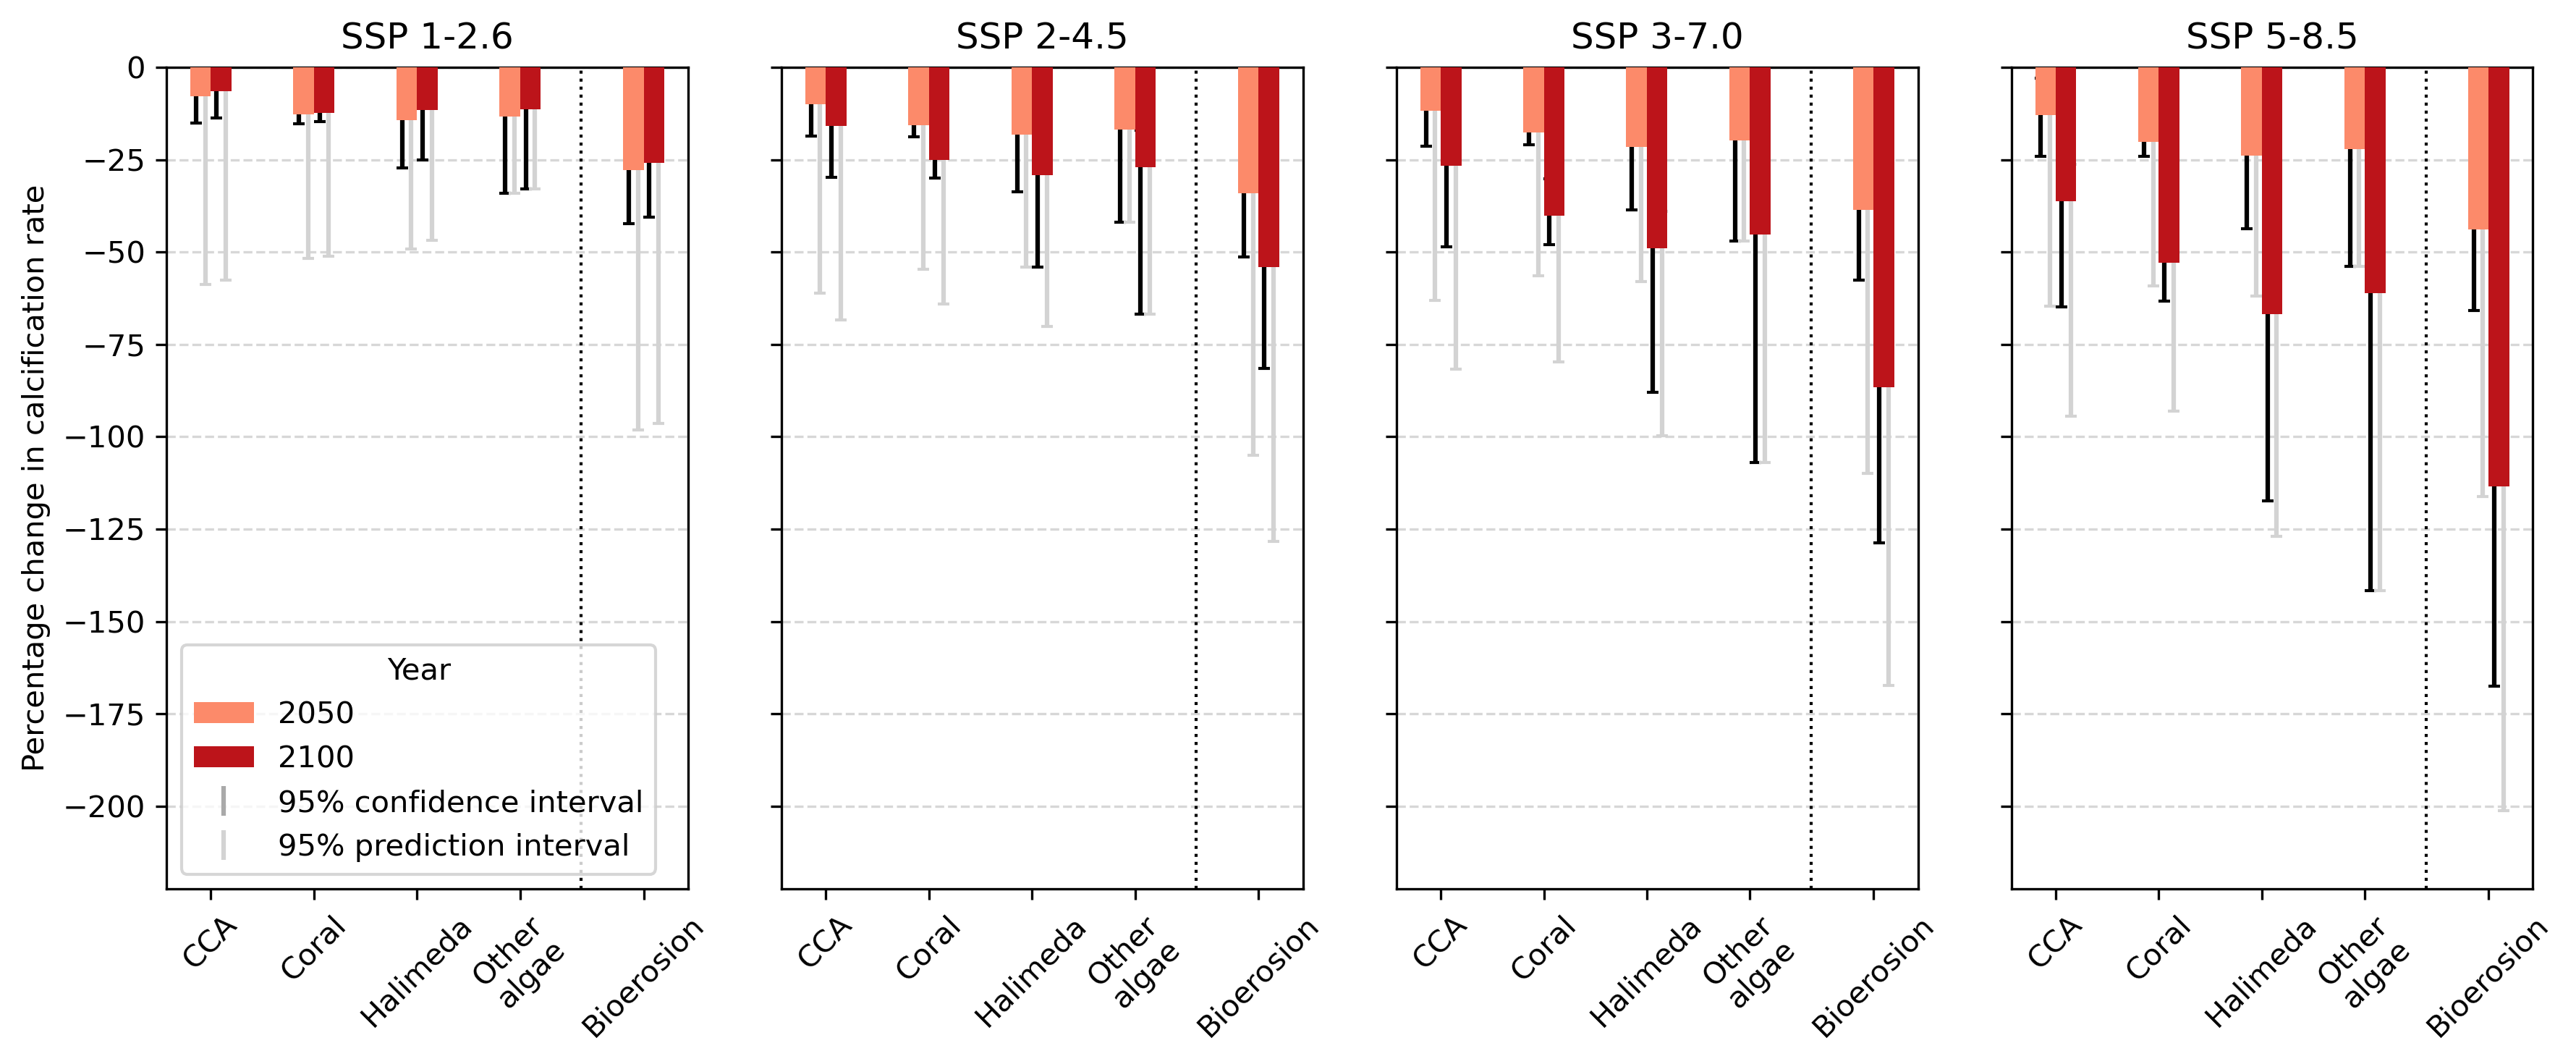

<Figure size 640x480 with 0 Axes>

In [625]:
# plot a bar graph (clustered by core_grouping and with the 95% CI as error bars), for each scenario at 2050 and 2100
# Filter for years 2050 and 2100
years_of_interest = [2050, 2100]
be_df_filtered = be_df[be_df["time_frame"].isin(years_of_interest)]
be_df_filtered = be_bio_df[be_bio_df["time_frame"].isin(years_of_interest)]
be_df_filtered = be_df_filtered[be_df_filtered["core_grouping"] != "Foraminifera"]

summary = (
    be_df_filtered.groupby(["scenario", "core_grouping", "time_frame"])
    .agg(
        mean_pred=("pred", "mean"),
        ci_lb=("ci_lb", "mean"),
        ci_ub=("ci_ub", "mean"),
        pi_lb=("pi_lb", "mean"),
        pi_ub=("pi_ub", "mean"),
    )
    .reset_index()
)

# Plot
scenarios = summary["scenario"].unique()
core_groupings = summary["core_grouping"].unique()
years = years_of_interest

# Order core_groupings alphabetically, but with "Bioerosion" last
ordered_core_groupings = sorted([cg for cg in core_groupings if cg != "Bioerosion"])
if "Bioerosion" in core_groupings:
    ordered_core_groupings.append("Bioerosion")

# For whitespace, add a gap between the last "normal" group and Bioerosion
gap = 1.2  # controls the width of the whitespace (should be >1 for visible gap)

# Compute x positions for each group, with a gap before Bioerosion
x_positions = []
for idx, cg in enumerate(ordered_core_groupings):
    if idx == 0:
        x_positions.append(0)
    elif cg == "Bioerosion":
        # Add gap before Bioerosion
        x_positions.append(x_positions[-1] + gap)
    else:
        x_positions.append(x_positions[-1] + 1)

x_positions = np.array(x_positions)

fig, axes = plt.subplots(
    1, len(scenarios), figsize=(3 * len(scenarios), 5), sharey=True, dpi=300
)

scenario_colours = sns.color_palette("Reds", len(scenarios))
colours = scenario_colours[1], scenario_colours[-1]

if len(scenarios) == 1:
    axes = [axes]

for ax, scenario in zip(axes, scenarios):
    data = summary[summary["scenario"] == scenario]
    bar_width = 0.2
    for i, year in enumerate(years):
        year_data = data[data["time_frame"] == year]
        means = [
            year_data[year_data["core_grouping"] == cg]["mean_pred"].values[0]
            if not year_data[year_data["core_grouping"] == cg].empty
            else np.nan
            for cg in ordered_core_groupings
        ]
        ci = [
            (
                year_data[year_data["core_grouping"] == cg]["ci_ub"].values[0]
                - year_data[year_data["core_grouping"] == cg]["ci_lb"].values[0]
            )
            / 2
            if not year_data[year_data["core_grouping"] == cg].empty
            else np.nan
            for cg in ordered_core_groupings
        ]
        pi = [
            (
                year_data[year_data["core_grouping"] == cg]["pi_ub"].values[0]
                - year_data[year_data["core_grouping"] == cg]["pi_lb"].values[0]
            )
            / 2
            if not year_data[year_data["core_grouping"] == cg].empty
            else np.nan
            for cg in ordered_core_groupings
        ]

        # Plot only the upper error bars (extending into the bars)
        ax.errorbar(
            x_positions + i * bar_width - bar_width / 4.5,
            [m + 10 for m in means],
            yerr=[[c + 10 for c in ci], np.zeros_like(ci)],
            fmt="none",
            capsize=2,
            barsabove=False,
            color="black",
        )
        ax.errorbar(
            x_positions + i * bar_width + bar_width / 4.5,
            [m + 10 for m in means],
            yerr=[[p + 10 for p in pi], np.zeros_like(pi)],
            fmt="none",
            capsize=2,
            barsabove=True,
            color="lightgrey",
        )
        ax.bar(
            x_positions + i * bar_width,
            means,
            width=bar_width,
            label=str(year),
            align="center",
            color=colours[i],
            zorder=10,
        )

    ax.set_ylim(
        be_df_filtered[
            (be_df_filtered["time_frame"] == 2100)
            & (be_df_filtered["percentile"] == "mean")
        ]["pi_lb"].min()
        * 1.1,
        0,
    )

    # Set xticks and labels
    ax.set_xticks(x_positions + bar_width / 2)
    xtick_labels = [cg.replace(" ", "\n") for cg in ordered_core_groupings]
    ax.set_xticklabels(xtick_labels, rotation=45, fontsize=10)

    # Draw a dotted vertical line between the last "real" group and Bioerosion
    if "Bioerosion" in ordered_core_groupings:
        bio_idx = ordered_core_groupings.index("Bioerosion")
        if bio_idx > 0:
            # Position for the vertical line: halfway between last normal and Bioerosion
            x_line = (x_positions[bio_idx - 1] + x_positions[bio_idx]) / 1.95
            ax.axvline(x_line, color="k", linestyle=":", linewidth=1)

    ax.set_title(f"{plot_config.SCENARIO_MAP[scenario]}")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

axes[0].errorbar(
    [],
    [],
    yerr=[],
    fmt="none",
    capsize=2,
    barsabove=True,
    color="darkgrey",
    label="95% confidence interval",
)
axes[0].errorbar(
    [],
    [],
    yerr=[],
    fmt="none",
    capsize=2,
    color="lightgrey",
    barsabove=True,
    label="95% prediction interval",
)
axes[0].legend(title="Year")
axes[0].set_ylabel("Percentage change in calcification rate", fontsize=10)
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()


In [ ]:
cg_grouped_df = be_bio_df.groupby("core_grouping")
n_coefs = 2
# via two-tailed t-distribution
out = pd.DataFrame()
for cg, cg_df in cg_grouped_df:
    # assign p-scores and certainty
    df = max(len(cg_df) - n_coefs, 1)
    cg_df = analysis_utils.assign_p_score_and_certainty(cg_df, df=df)
    out = pd.concat([out, cg_df])

In [ ]:
for cg in results[0].keys():
    print(results[0][cg]["model"].get_heterogeneity_dataframe())

            QE  QEp          QM           QMp    sigma2.1    sigma2.2
0  9351.376777  0.0  102.542766  5.409053e-23  391.223726  542.076299
            QE  QEp         QM       QMp   sigma2.1     sigma2.2
0  3122.206374  0.0  17.451417  0.000162  662.88793  1000.858709
           QE            QEp         QM       QMp    sigma2.1     sigma2.2
0  846.423248  5.530197e-137  23.454733  0.000008  271.088008  2739.123287
           QE           QEp        QM       QMp  sigma2.1     sigma2.2
0  189.997272  8.261634e-32  4.897015  0.086422  0.000259  2788.859963


In [664]:
    out[(out.scenario == "ssp585") & (out.time_frame == 2100)][
        out[(out.scenario == "ssp585") & (out.time_frame == 2100)]["percentile"]
        == "p90"
    ].anomaly_value_sst

983     4.789979
1019    4.706249
1019    4.706249
1019    4.706249
1019    4.706249
Name: anomaly_value_sst, dtype: float64

In [665]:
(
    out[(out.scenario == "ssp585") & (out.time_frame == 2100)][
        out[(out.scenario == "ssp585") & (out.time_frame == 2100)]["percentile"]
        == "p90"
    ].anomaly_value_sst.iloc[0]
    - out[(out.scenario == "ssp585") & (out.time_frame == 2100)][
        out[(out.scenario == "ssp585") & (out.time_frame == 2100)]["percentile"]
        == "mean"
    ].anomaly_value_sst.iloc[0]
)

np.float64(0.8046821403800779)

In [597]:
out[out.time_frame.isin([2050, 2100]) & (out.percentile == "mean")]

,scenario,time_frame,percentile,anomaly_value_ph,anomaly_value_sst,core_grouping,pred,se,ci_lb,ci_ub,pi_lb,pi_ub,p_score,certainty
31,ssp126,2050,mean,-0.087191,1.101334,Bioerosion,-27.900417,7.381959,-42.368791,-13.432042,-98.169836,42.369003,0.000167,3
81,ssp126,2100,mean,-0.068446,1.146279,Bioerosion,-25.999722,7.493801,-40.687303,-11.312141,-96.314603,44.315159,0.000544,3
277,ssp245,2050,mean,-0.112172,1.272074,Bioerosion,-33.684070,8.627493,-50.593646,-16.774494,-104.496437,37.128297,0.000101,3
327,ssp245,2100,mean,-0.178735,2.057082,Bioerosion,-54.155515,13.935047,-81.467706,-26.843324,-128.144793,19.833763,0.000109,3
523,ssp370,2050,mean,-0.134012,1.354641,Bioerosion,-37.878840,9.389974,-56.282851,-19.474830,-109.062863,33.305183,0.000059,3
573,ssp370,2100,mean,-0.304875,3.095331,Bioerosion,-86.360638,21.423959,-128.350826,-44.370449,-166.931311,-5.789964,0.000060,3
769,ssp585,2050,mean,-0.148037,1.616524,Bioerosion,-43.572152,11.036271,-65.202846,-21.941458,-115.657826,28.513522,0.000084,3
819,ssp585,2100,mean,-0.416808,3.985297,Bioerosion,-114.358863,27.895308,-169.032662,-59.685063,-202.209200,-26.508525,0.000045,3
32,ssp126,2050,mean,-0.090347,1.026243,CCA,-7.825189,3.658059,-14.994862,-0.655517,-58.794465,43.144086,0.032668,2
84,ssp126,2100,mean,-0.071842,1.078291,CCA,-6.512195,3.650148,-13.666362,0.641972,-57.479292,44.454902,0.074718,1


/Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/calc-rates/calcification/plotting/analysis.py:2043: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.15, 1, 0.97])


(<Figure size 4200x1800 with 4 Axes>,
 <Axes: ylabel='Sea surface temperature anomaly (°C)'>)

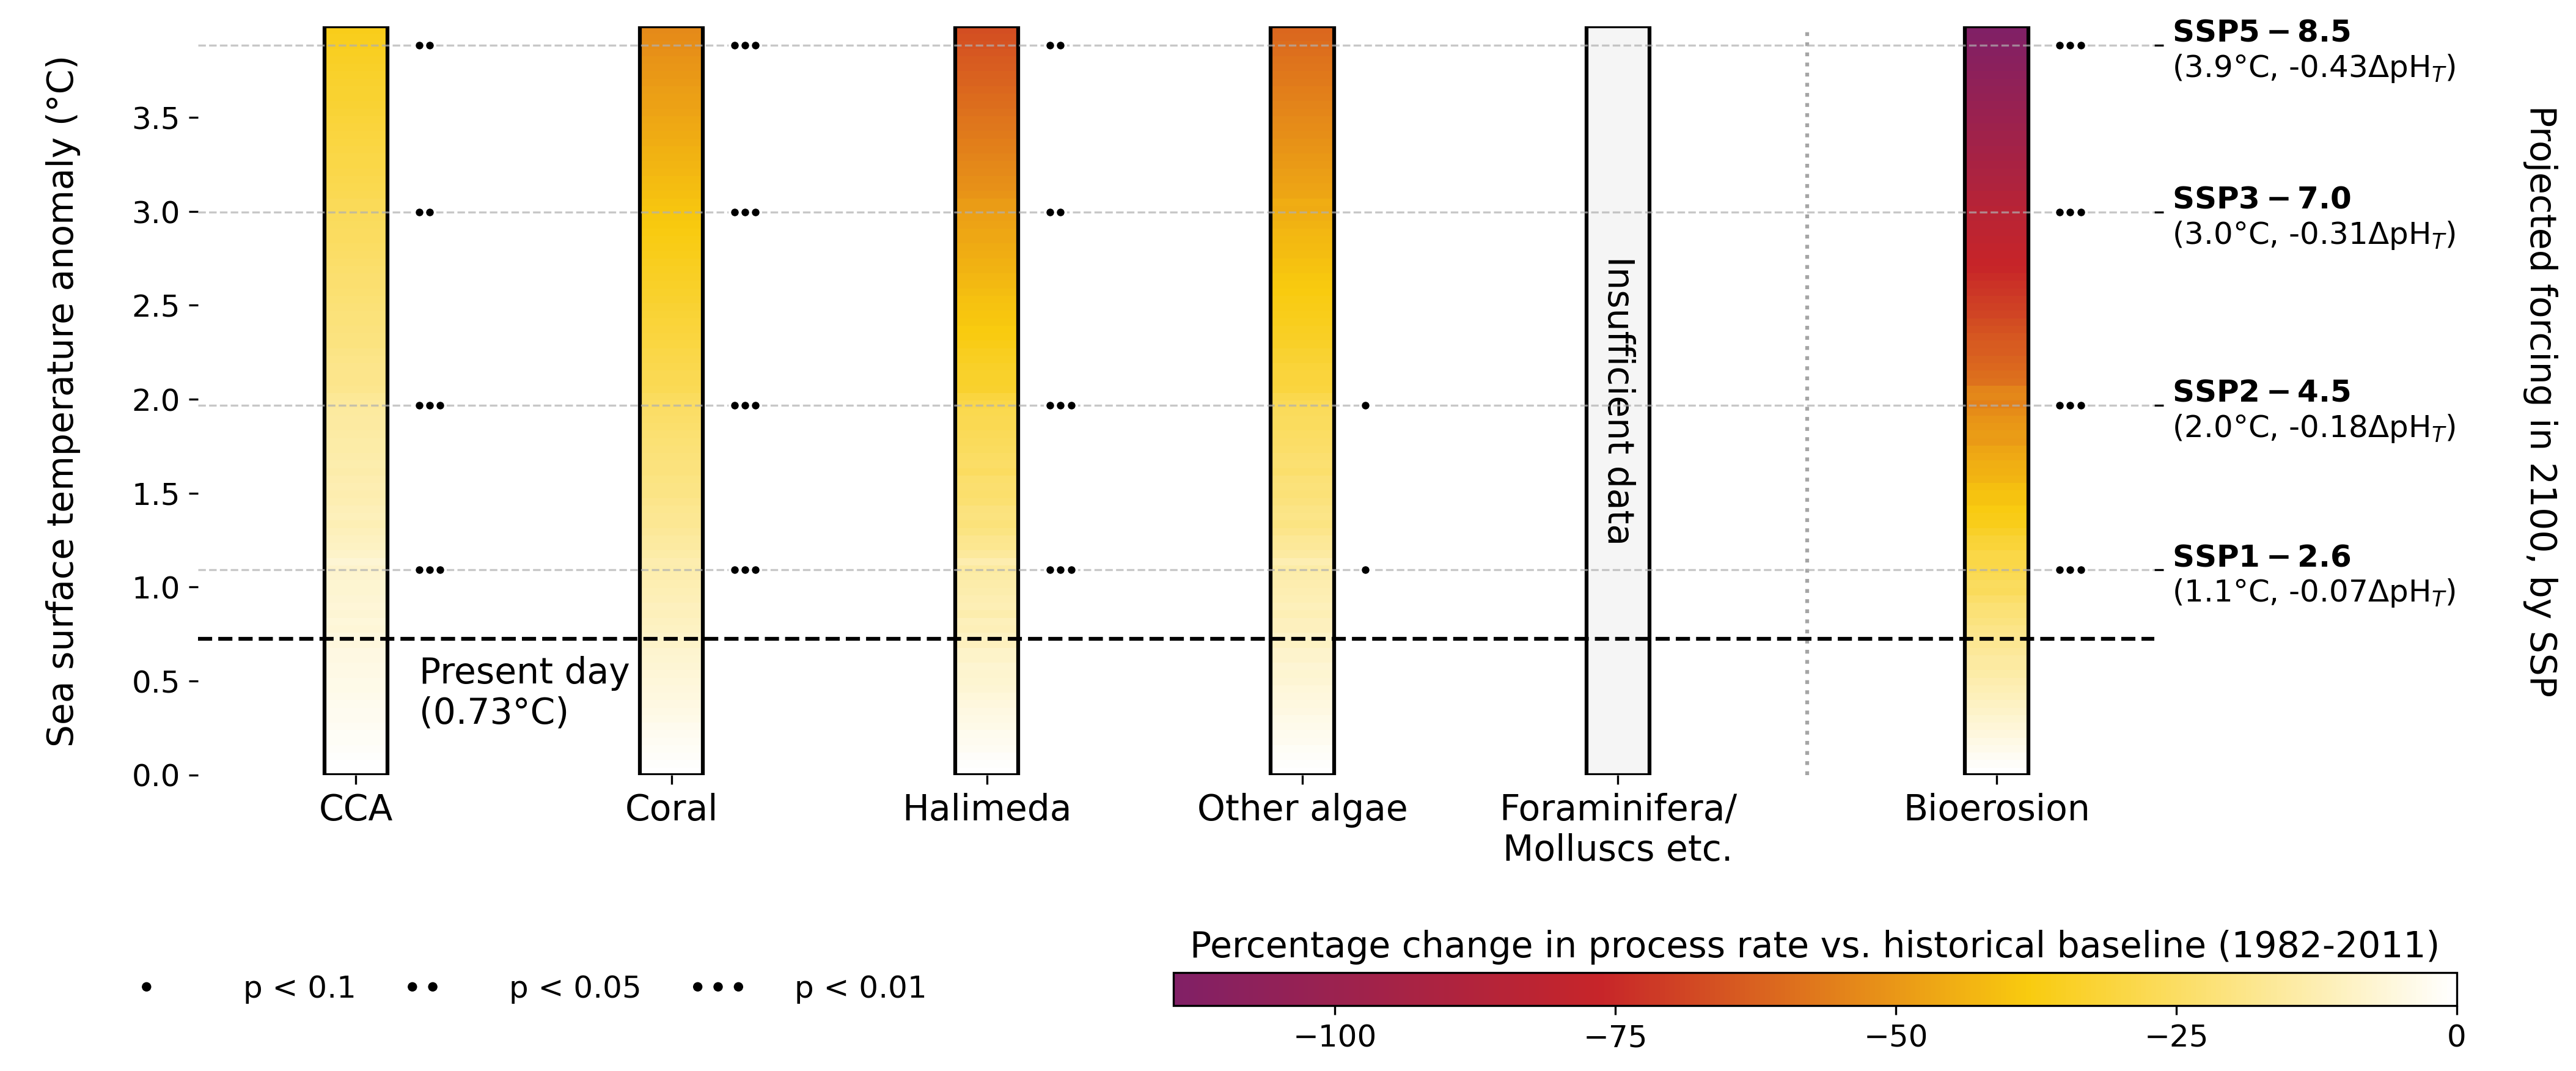

In [650]:
analysis_plot.BurningEmbersPlotter(
    out,
    config=analysis_plot.BurningEmbersConfig(
        forcing_col="anomaly_value_sst",
        title="",
        category_order=[
            "CCA",
            "Coral",
            "Halimeda",
            "Other algae",
            "Foraminifera/\nMolluscs etc.",
            "Bioerosion",
        ],
        shift_bioerosion=True,
        pi_exceedance=False,
        se_dots=True,
    ),
).plot()

In [669]:
plot_utils.save_dir_png_to_jpg(
    "/Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/calc-rates/figures/new_final"
)

(<Figure size 4200x3600 with 20 Axes>,
 array([[<Axes: title={'center': 'CCA'}>,
         <Axes: title={'center': 'Coral'}>,
         <Axes: title={'center': 'Halimeda'}>,
         <Axes: title={'center': 'Other algae'}>,
         <Axes: title={'center': 'Bioerosion'}>],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

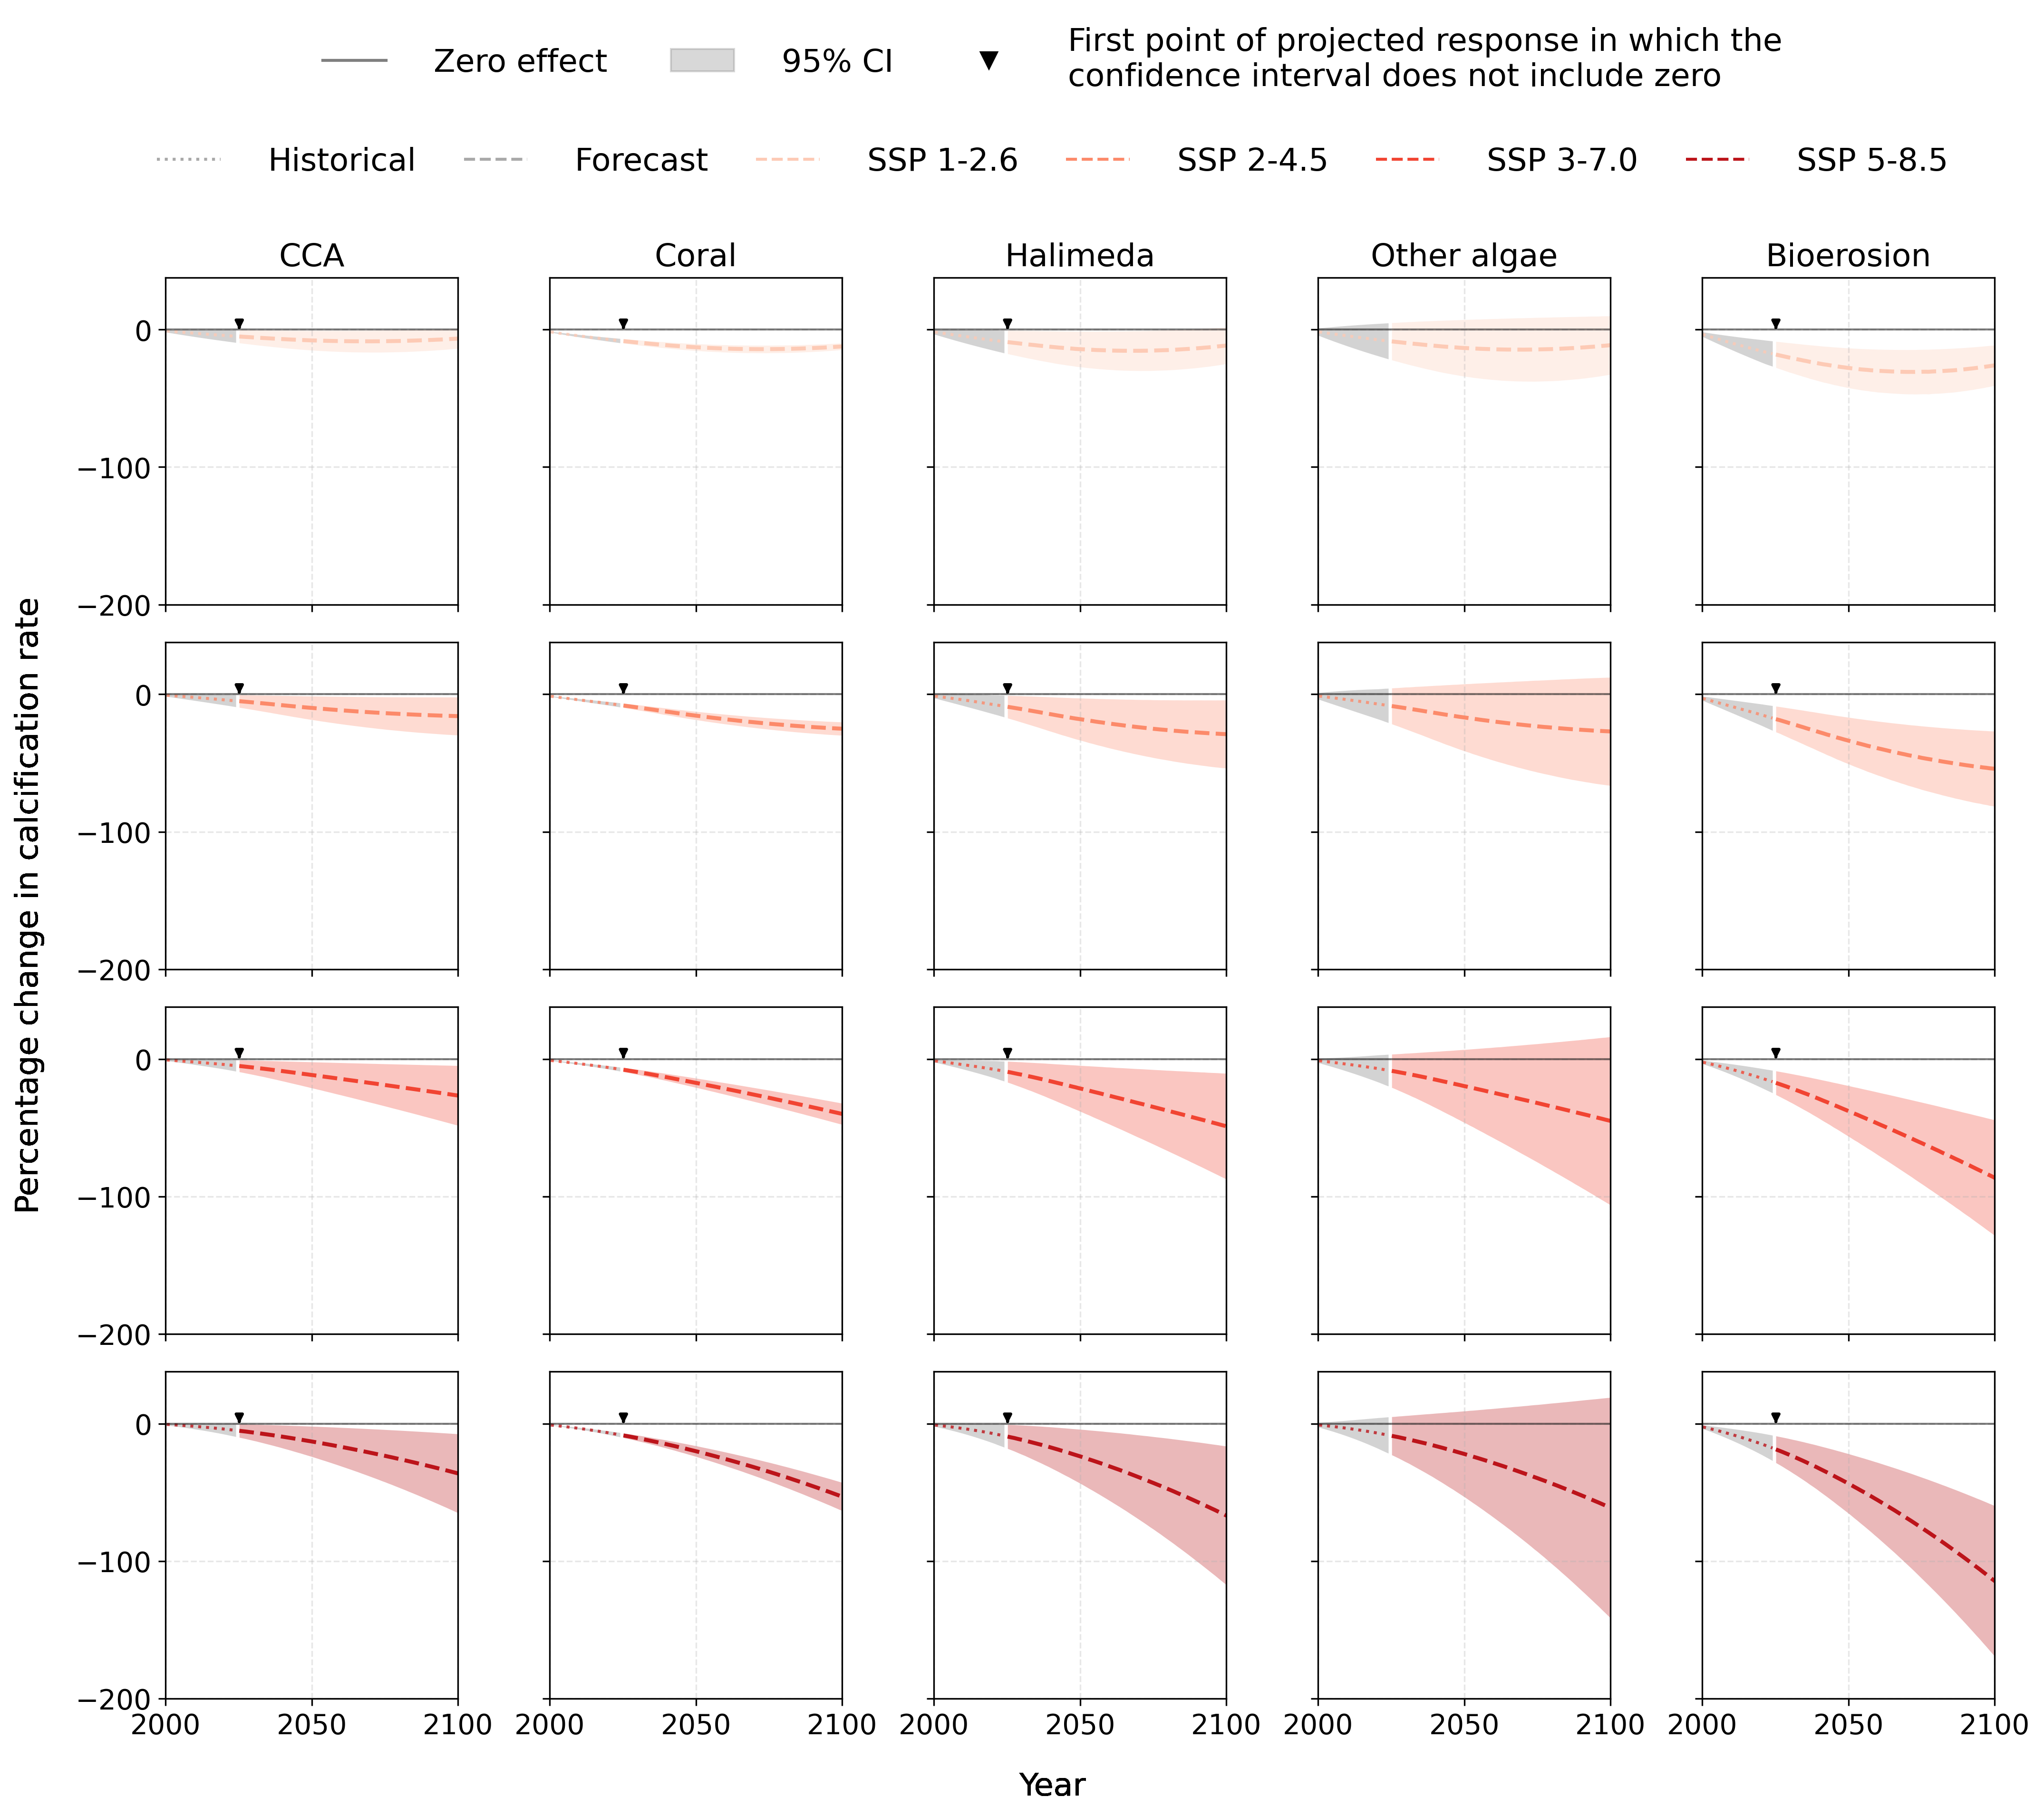

In [668]:
# # generate dictionary of group and results
# group_results_dict = {}
# for group in be_bio_df["core_grouping"].unique():
#     if group != "Foraminifera":
#         group_results_dict[group] = be_bio_df[be_bio_df["core_grouping"] == group]

# # move bioerosion to the bottom
# group_results_dict["Bioerosion"] = group_results_dict.pop("Bioerosion")

analysis_plot.plot_global_timeseries_grid(group_results_dict, figsize=(14, 12))

In [ ]:
results[0]["Coral"]["model"].model_dict.get("k", [100])


In [ ]:
results

In [ ]:
# compute ci columns using t-test of prediction and se

cg = "Coral"
n_obs = results[0][cg]["model"].model_dict.get("k", [100])
n_coefs = results[0][cg]["model"].get_model_metadata()["n_coefficients"]
dof = max(n_obs - n_coefs, 1)

alpha = 0.05
from scipy.stats import t as scipy_t

t_score = scipy_t.ppf(1 - alpha / 2, dof)

pred = group_results_dict[cg]["pred"]
se = group_results_dict[cg]["se"]
ci_lb = pred - t_score * se
ci_ub = pred + t_score * se


group_results_dict[cg].loc["tt_ci_lb", :] = ci_lb
group_results_dict[cg].loc["tt_ci_ub", :] = ci_ub

# test for significance of effect size (null hypothesis is effect size = 0)
# analysis_utils.p_score(group_results_dict[cg]["pred"], group_results_dict[cg]["se"])
group_results_dict[cg].apply(
    lambda row: analysis_utils.p_score(row["pred"], row["se"], null_value=0), axis=1
)

# group_results_dict[cg]

In [ ]:
be_bio_df[
    (be_bio_df["percentile"] == "mean")
    & (be_bio_df["scenario"].isin(["ssp585", "ssp245"]))
    & (be_bio_df["time_frame"] == 2100)
    & (~be_bio_df["core_grouping"].isin(["Foraminifera", "Bioerosion"]))
]

In [ ]:
min_dp


In [ ]:
cg = "Halimeda"
plot_var = "ci_ub"

cg_df = clim_data_df[clim_data_df["core_grouping"] == cg]

min_dt = cg_df["delta_t"].min()
max_dt = cg_df["delta_t"].max()
min_dp = cg_df["delta_ph"].min()
max_dp = cg_df["delta_ph"].max()

model = models_dict[cg]
model_surface, meshgrids = model.predict_nd_surface_from_model(
    moderator_names=["delta_t", "delta_ph"],
    moderator_values=[
        np.linspace(0, max_dt, 1000),
        np.linspace(min_dp, max_dp, 1000),
    ],
)
# contour plot
contour_plot = plt.contourf(
    meshgrids[0],
    meshgrids[1],
    model_surface[plot_var],
    50,
    vmin=-np.max(np.abs(model_surface[plot_var])),
    vmax=np.max(np.abs(model_surface[plot_var])),
    cmap="RdBu",
)
# for each ssp, add a line denoting the ph and temp anomalies
for ssp in be_bio_df["scenario"].unique():
    ssp_df = be_bio_df[
        (be_bio_df["scenario"] == ssp)
        & (be_bio_df["percentile"] == "mean")
        & (be_bio_df["core_grouping"] == cg)
    ]
    plt.plot(ssp_df["anomaly_value_sst"], ssp_df["anomaly_value_ph"], label=ssp)
plt.legend()
plt.xlabel("SST anomaly")
plt.ylabel("pH anomaly")
plt.title(cg.upper())
plt.colorbar(contour_plot)


# Effect sizes

In [ ]:
working_effects_df = clim_data_df.copy()
# remove foraminifera rows
working_effects_df = working_effects_df[
    working_effects_df["core_grouping"] != "Foraminifera"
]


In [ ]:
ordered_working_effects_df.core_grouping.value_counts()

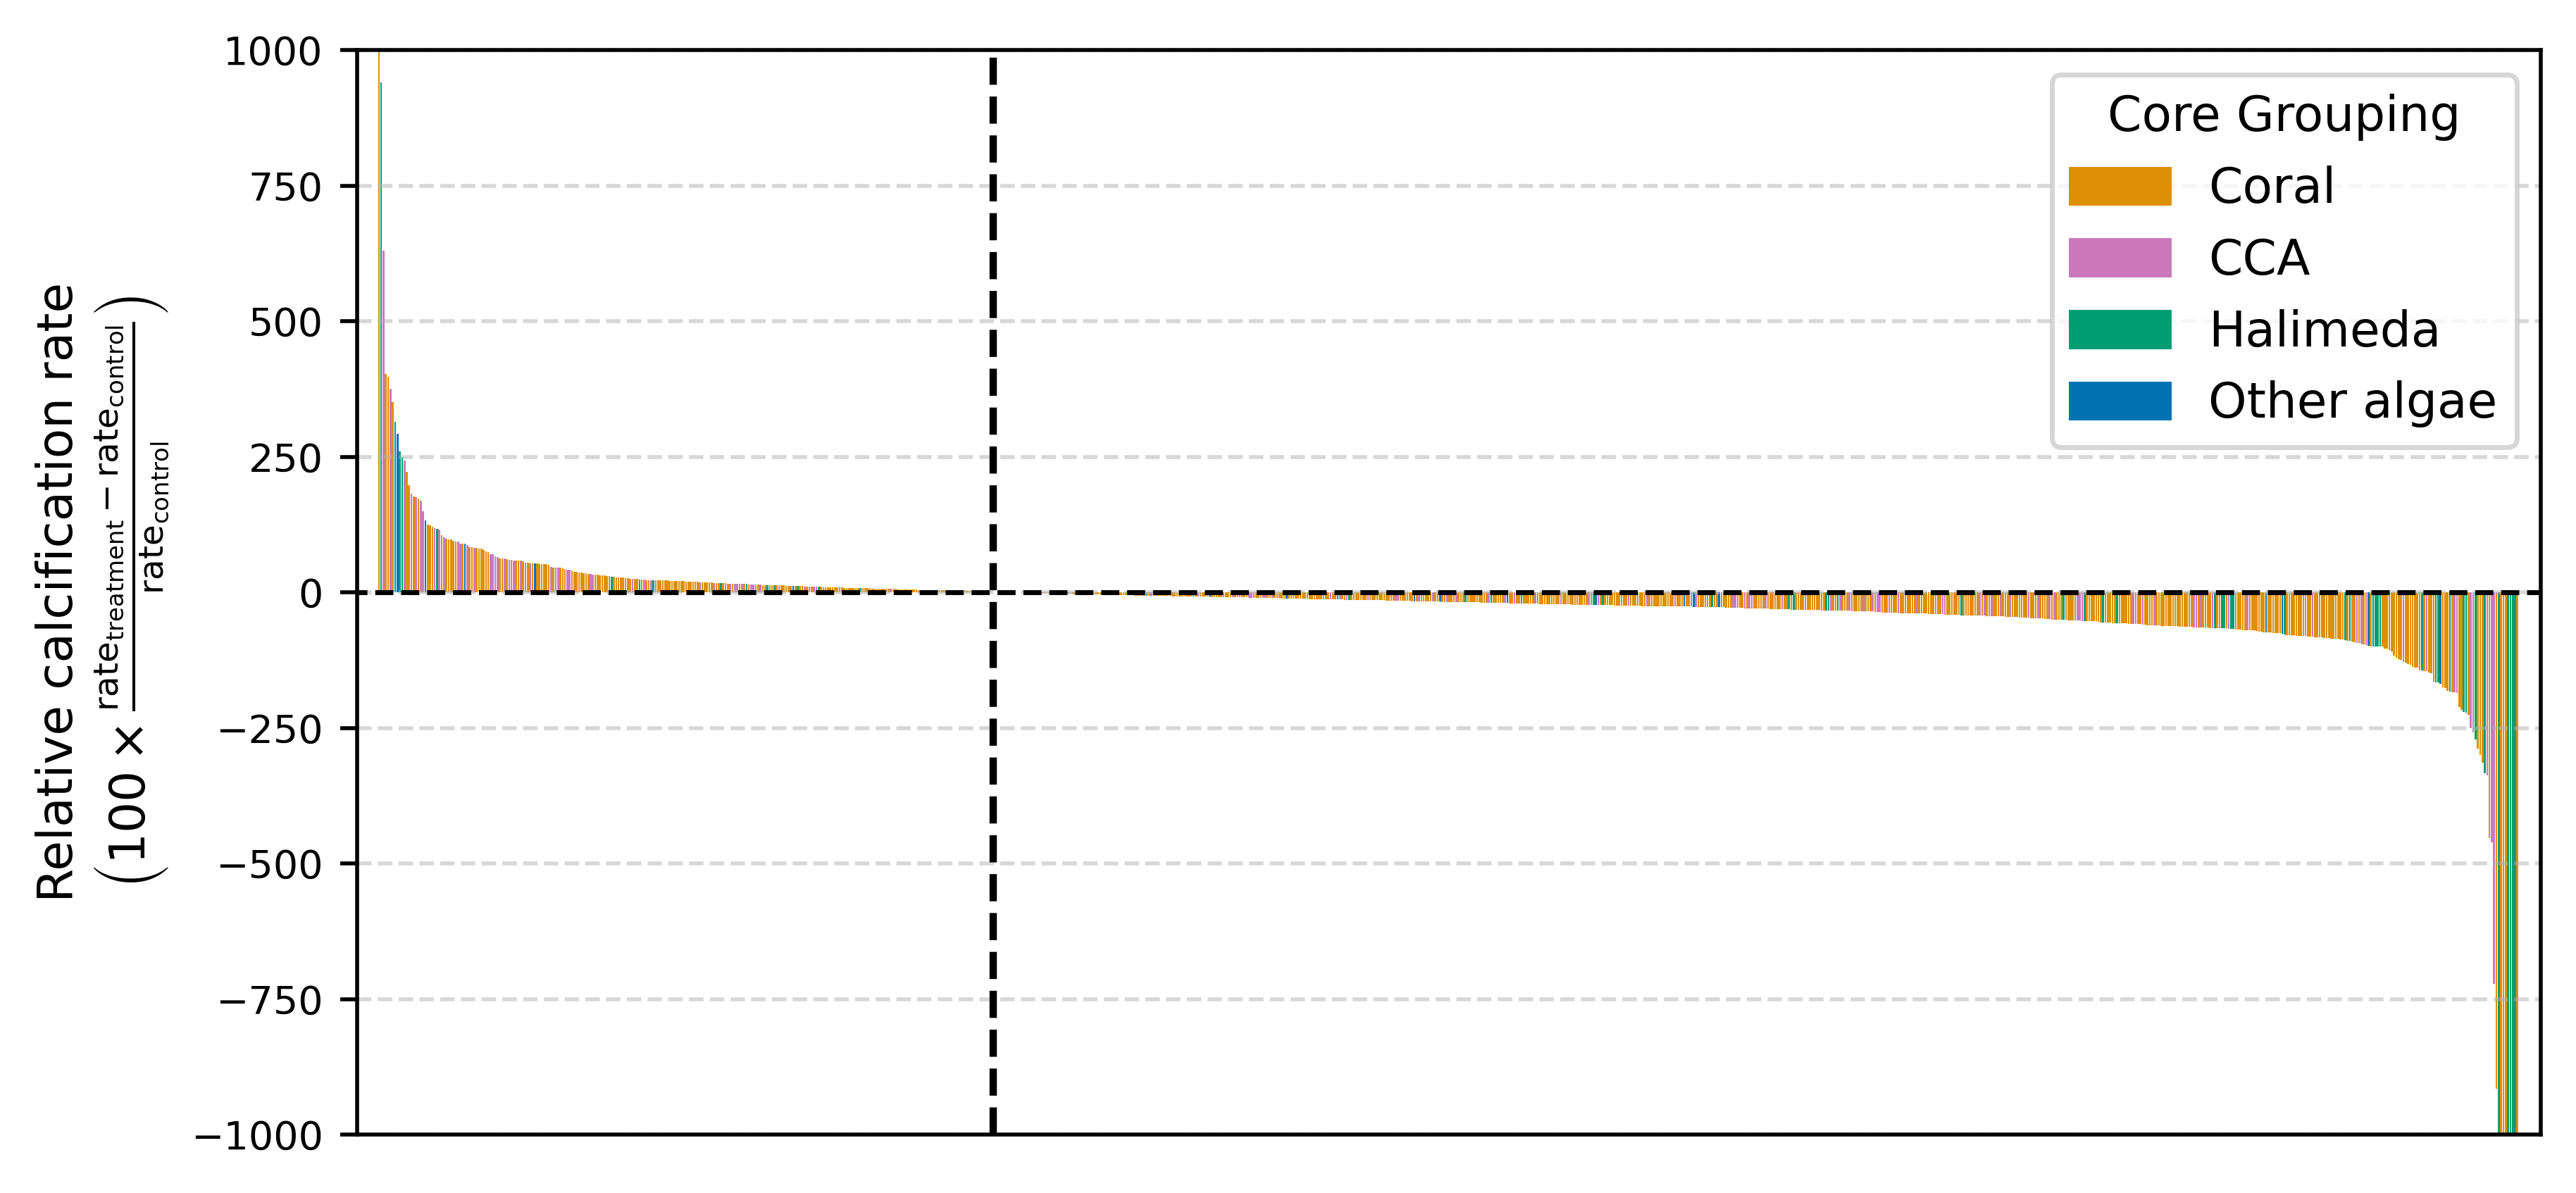

In [631]:
ordered_working_effects_df = (
    working_effects_df.sort_values(by="st_relative_calcification", ascending=False)
    .reset_index(drop=True)
    .copy()
)


# Map core_grouping to colors
unique_groups = ordered_working_effects_df["core_grouping"].unique()

# Plot the bar chart
fig, ax = plt.subplots(figsize=(8, 4), dpi=500)
ax.bar(
    np.arange(len(ordered_working_effects_df)),
    ordered_working_effects_df["st_relative_calcification"],
    color=ordered_working_effects_df["core_grouping"].map(plot_config.CG_COLOURS),
)
ax.hlines(0, *ax.get_xlim(), color="black", linestyle="--", linewidth=1)
ax.set_ylim(-1000, 1000)
ax.set_xticks([])
# Add labels and title
ax.set_ylabel(
    "Relative calcification rate"
    "\n"
    r"$\left(100 \times \frac{\mathrm{rate_{treatment}} - \mathrm{rate_{control}}}{\mathrm{rate_{control}}}\right)$"
)
ax.grid(ls="--", alpha=0.5)
ax.set_xlim(
    -len(ordered_working_effects_df.index) * 0.01,
    len(ordered_working_effects_df.index) * 1.01,
)
ax.tick_params(axis="y", labelsize=8)
# Add a legend for core_grouping
handles = [
    Patch(color=color, label=group)
    for group, color in plot_config.CG_COLOURS.items()
    if group != "Foraminifera"
]
ax.legend(handles=handles, title="Core Grouping", loc="upper right")
first_zero_idx = ordered_working_effects_df[
    ordered_working_effects_df["st_relative_calcification"] <= 0
].index[0]
ax.vlines(
    first_zero_idx,
    *ax.get_ylim(),
    color="black",
    linestyle="--",
)


In [ ]:
### visualising standardised units
plt.figure(figsize=(15, 4))
count_order = (
    data_df["st_calcification_unit"].value_counts().index
)  # sort by number of counts for each calcification unit
# plot
sns.countplot(
    data=data_df,
    x="st_calcification_unit",
    order=count_order,
    palette="Set2",
    hue="st_calcification_unit",
)
# format
plt.xticks(rotation=90)
plt.grid(ls="--", alpha=0.5)
for p in plt.gca().patches:
    plt.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=12,
        color="black",
        xytext=(0, 5),
        textcoords="offset points",
    )
plt.ylim(0, data_df["st_calcification_unit"].value_counts().max() * 1.1)
# report
print(
    f"Number of distinct types of calcification measurement: {len(data_df['st_calcification_unit'].unique())}"
)


In [ ]:
### visualising standardised units with total samples (n)
plt.figure(figsize=(15, 4))

unit_counts = (
    data_df.groupby("st_calcification_unit")["n"].sum().sort_values(ascending=False)
)  # group by 'st_calcification_unit' and sum the 'n' column
# plot
sns.barplot(
    x=unit_counts.index, y=unit_counts.values, palette="Set2", hue=unit_counts.index
)
# format
plt.xticks(rotation=90)
plt.grid(ls="--", alpha=0.5)
for i, value in enumerate(unit_counts.values):
    plt.annotate(
        f"{int(value)}",
        (i, value),
        ha="center",
        va="bottom",
        fontsize=12,
        color="black",
        xytext=(0, 5),
        textcoords="offset points",
    )
plt.ylim(0, unit_counts.max() * 1.1)
# report
print(f"Number of distinct types of calcification measurement: {len(unit_counts)}")


/var/folders/tp/x_9dbyf149d6kw_k79l_kk4m0000gq/T/ipykernel_15239/3239744578.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


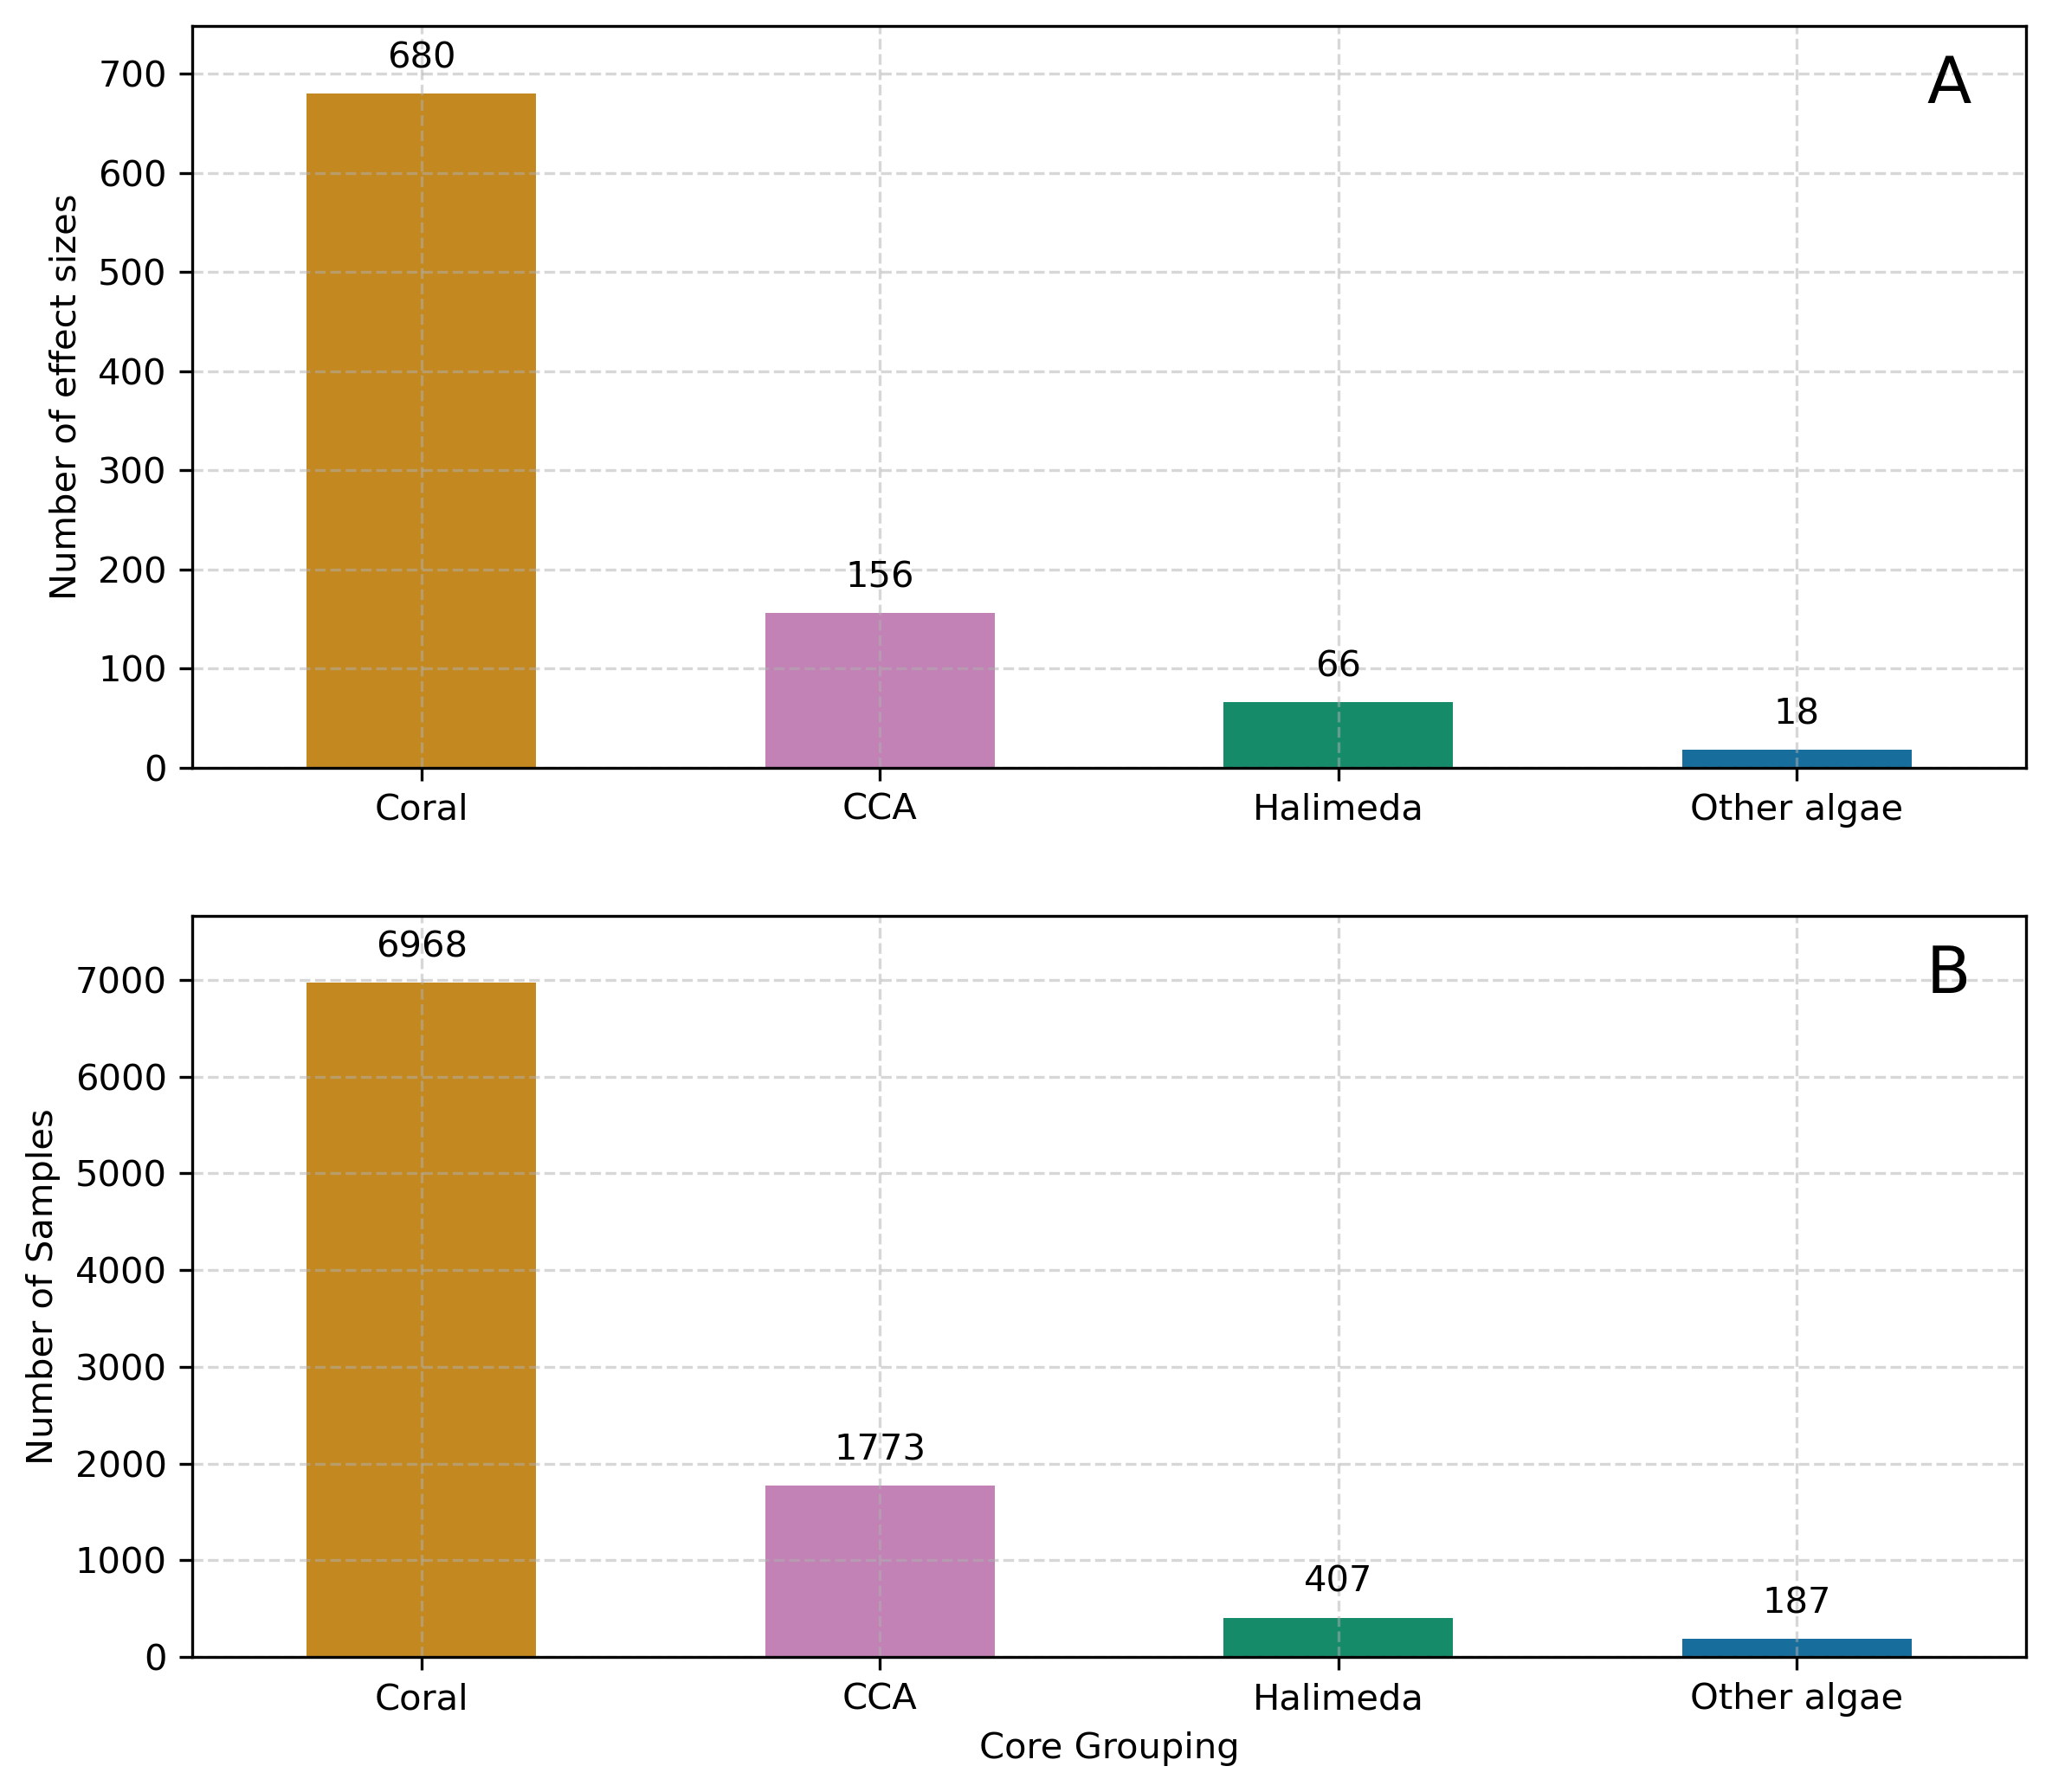

In [627]:
### Combined visualization of the number of effect sizes per core grouping and by number of samples
fig, axes = plt.subplots(2, 1, figsize=(8, 7), dpi=300, sharex=False)

colours = plot_config.CG_COLOURS

# Plot 1: Number of effect sizes per core grouping
count_order = (
    working_effects_df["core_grouping"].value_counts().index
)  # order by number of effect sizes
sns.countplot(
    data=working_effects_df,
    x="core_grouping",
    order=count_order,
    palette=colours,
    hue="core_grouping",
    ax=axes[0],
    width=0.5,
)
# Format
for p in axes[0].patches:
    axes[0].annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        xytext=(0, 5),
        textcoords="offset points",
    )
axes[0].set_ylim(0, working_effects_df["core_grouping"].value_counts().max() * 1.1)
# axes[0].set_title('Number of Effect Sizes per Core Grouping', fontsize=12)
# axes[0].set_xlabel('Core Grouping')
axes[0].set_ylabel("Number of effect sizes")
axes[0].grid(ls="--", alpha=0.5)

# Plot 2: Number of effect sizes per core grouping by number of samples
cg_sample_counts = (
    working_effects_df.groupby("core_grouping")["n"].sum().sort_values(ascending=False)
)
sns.barplot(
    x=cg_sample_counts.index,
    y=cg_sample_counts.values,
    palette=colours,
    ax=axes[1],
    width=0.5,
)
# Format
for p in axes[1].patches:
    axes[1].annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        xytext=(0, 5),
        textcoords="offset points",
    )
axes[1].set_ylim(0, cg_sample_counts.max() * 1.1)
# axes[1].set_title('Number of Samples Corresponding to Effect Sizes per Core Grouping', fontsize=12)
axes[1].set_xlabel("Core Grouping")
axes[1].set_ylabel("Number of Samples")
axes[1].grid(ls="--", alpha=0.5)
axes[0].set_xlabel(" ")

for i, ax in enumerate(axes.flatten()):
    # fetch coordinates of top right hand corner of specific axis
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    # annotate with letter
    ax.annotate(
        chr(65 + i),
        xy=(0.97, 0.92),
        xycoords="axes fraction",
        fontsize=18,
        ha="right",
        va="center",
        # bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white')
    )

# Adjust layout
plt.tight_layout()
plt.show()


/var/folders/tp/x_9dbyf149d6kw_k79l_kk4m0000gq/T/ipykernel_15239/3223297686.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(["Overall"])
/var/folders/tp/x_9dbyf149d6kw_k79l_kk4m0000gq/T/ipykernel_15239/3223297686.py:150: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_yticklabels(


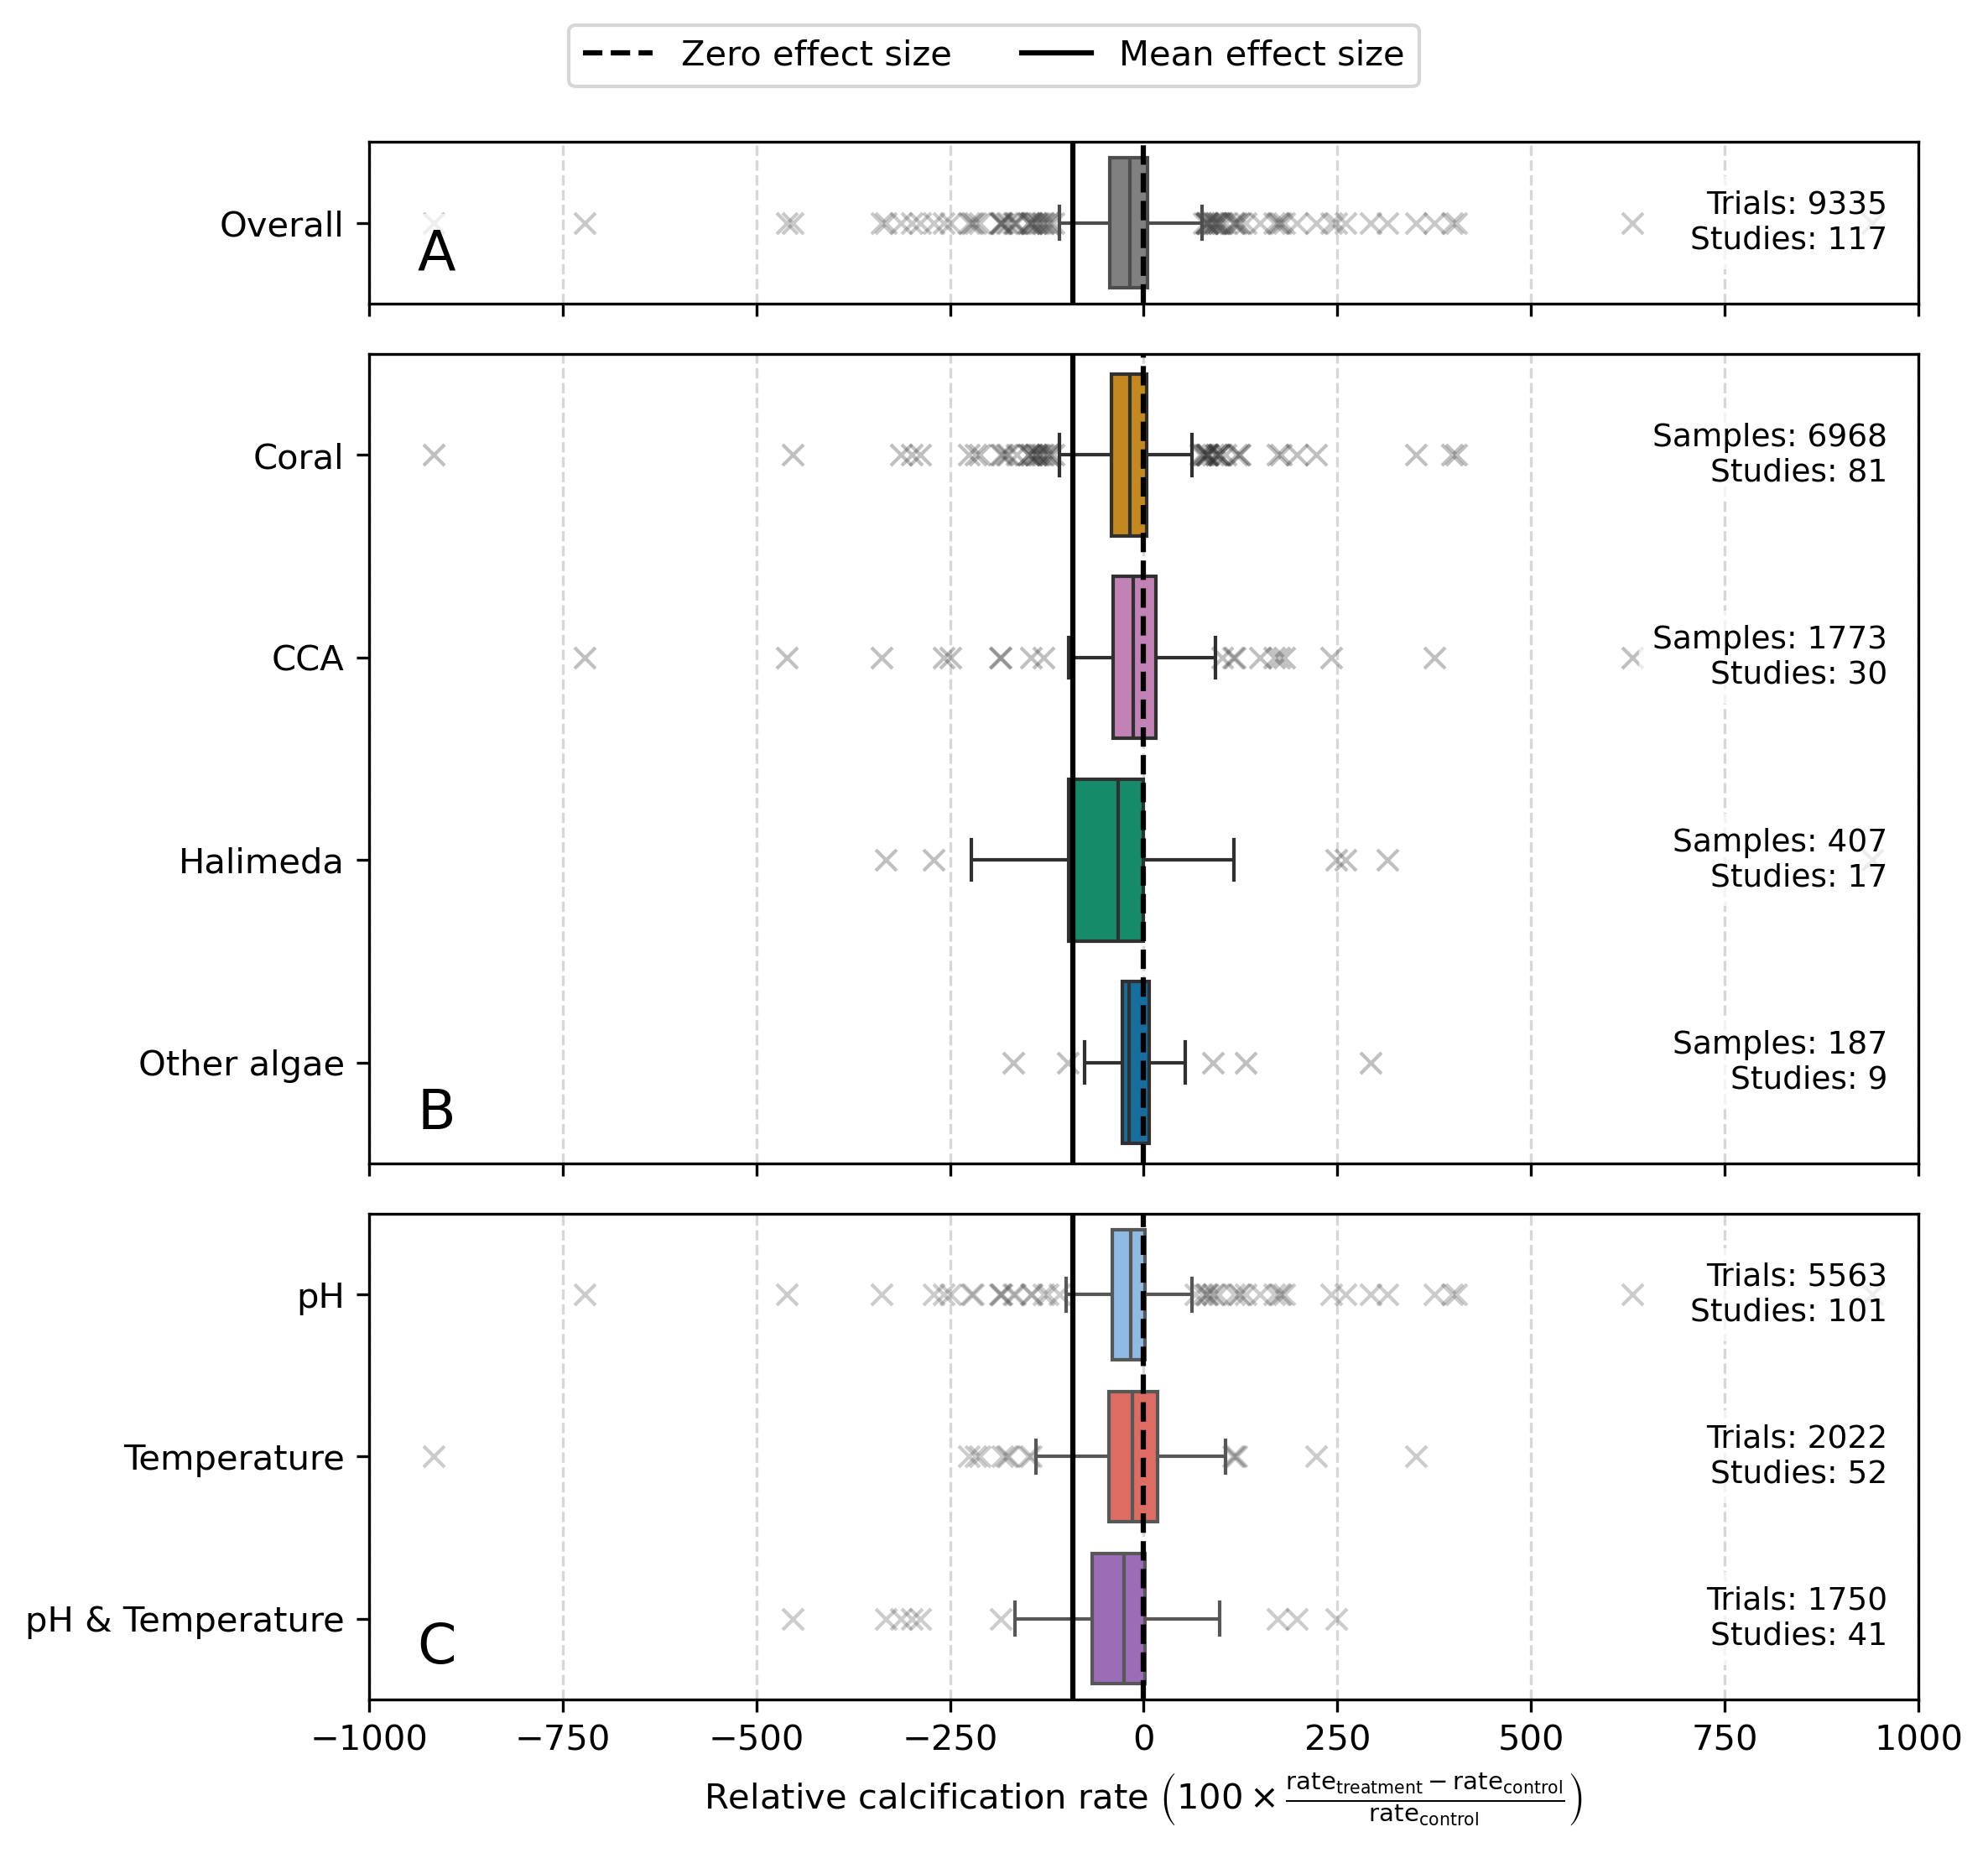

<Figure size 640x480 with 0 Axes>

In [628]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

effect_type = "st_relative_calcification"


working_df = working_effects_df.copy()

# --- Add 'overall' category for both core_grouping and treatment ---
# For overall: add a row for 'overall' with all data (for both core_grouping and treatment)
overall_df = working_df.copy()
overall_df = overall_df.assign(core_grouping="overall", treatment="overall")

# For plotting, do NOT append 'overall' to the main dataframes, but plot it on its own axis
plot_df_core = working_df.copy()
plot_df_treatment = working_df.copy()
plot_df_overall = overall_df.copy()

# --- PLOT ---
fig, axes = plt.subplots(
    3,
    1,
    figsize=(8, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [0.2, 1, 0.6]},
    dpi=300,
)

# create palette from CG_COLOURS dictionary, add 'overall' as grey
palette = {group: color for group, color in plot_config.CG_COLOURS.items()}
palette["overall"] = "grey"

# --- Ensure correct order for plotting ---

# Panel A: Grouped by core_grouping
if hasattr(plot_config, "CG_COLOURS"):
    core_grouping_order = [
        k for k in plot_config.CG_COLOURS.keys() if k != "Foraminifera"
    ]
else:
    core_grouping_order = sorted(working_df["core_grouping"].unique())

sns.boxplot(
    capwidths=0.2,
    flierprops={"marker": "x", "alpha": 0.3},
    data=plot_df_overall,
    x=effect_type,
    y="core_grouping",  # or "treatment", both are "overall"
    ax=axes[0],
    palette={"overall": "grey"},
    order=["overall"],
    hue="core_grouping",
    legend=False,
)
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_ylabel("")
axes[0].set_yticklabels(["Overall"])
axes[0].axvline(
    plot_df_overall[effect_type].mean(),
    color="black",
    label="Mean effect size",
)
# Add annotation for number of trials and studies (Panel C)
group_df = plot_df_overall
n_samples = group_df["n"].sum()
n_studies = (
    group_df["original_doi"].nunique()
    # if "original_doi" in group_df.columns
    # else group_df["doi"].nunique()
)
axes[0].text(
    0.98,
    0.5,
    f"Trials: {int(n_samples)}\nStudies: {n_studies}",
    transform=axes[0].transAxes,
    ha="right",
    va="center",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
)

sns.boxplot(
    capwidths=0.2,
    flierprops={"marker": "x", "alpha": 0.3},
    data=plot_df_core,
    x=effect_type,
    y="core_grouping",
    ax=axes[1],
    palette=palette,
    order=core_grouping_order,
    hue="core_grouping",
    legend=False,
)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_ylabel("")
axes[1].axvline(
    plot_df_core[effect_type].mean(),
    color="black",
    label="Mean effect size",
)

# Add annotation for number of trials and studies (Panel A) for each core_grouping
for i, core_group in enumerate(core_grouping_order):
    group_df = plot_df_core[plot_df_core["core_grouping"] == core_group]
    n_samples = group_df["n"].sum()
    n_studies = (
        group_df["original_doi"].nunique()
        if "original_doi" in group_df.columns
        else group_df["doi"].nunique()
    )
    y_pos = i
    axes[1].text(
        0.98,
        1 - ((y_pos + 0.5) / len(core_grouping_order)),  # distribute from top to bottom
        f"Samples: {int(n_samples)}\nStudies: {n_studies}",
        transform=axes[1].transAxes,
        ha="right",
        va="center",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )

# Panel B: Grouped by treatment_type
treatment_order = ["phtot", "temp", "temp_phtot"]
treatment_order = [t for t in treatment_order if t in working_df["treatment"].unique()]
other_treatments = [
    t for t in working_df["treatment"].unique() if t not in treatment_order
]
treatment_order += other_treatments

treatment_palette = {
    t: plot_config.TREATMENT_COLOURS.get(t, "Set3") for t in treatment_order
}

sns.boxplot(
    capwidths=0.2,
    flierprops={"marker": "x", "alpha": 0.3},
    data=plot_df_treatment,
    x=effect_type,
    y="treatment",
    ax=axes[2],
    palette=treatment_palette,
    order=treatment_order,
    hue="treatment",
    legend=False,
)

# rewrite treatment labels on y axis using the treatment_mapping dictionary
axes[2].set_yticklabels(
    [plot_config.TREATMENT_MAPPING.get(t, t) for t in treatment_order]
)

axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_xlabel(
    r"Relative calcification rate $\left(100 \times \frac{\mathrm{rate_{treatment}} - \mathrm{rate_{control}}}{\mathrm{rate_{control}}}\right)$"
)

axes[2].set_ylabel("")
axes[2].axvline(
    plot_df_treatment[effect_type].mean(),
    color="black",
    label="Mean effect size",
)

# Add annotation for number of trials and studies (Panel B) for each treatment
for i, treatment in enumerate(treatment_order):
    group_df = plot_df_treatment[plot_df_treatment["treatment"] == treatment]
    n_samples = group_df["n"].sum()
    n_studies = (
        group_df["original_doi"].nunique()
        if "original_doi" in group_df.columns
        else group_df["doi"].nunique()
    )
    y_pos = i
    axes[2].text(
        0.98,
        1 - ((y_pos + 0.5) / len(treatment_order)),  # distribute from top to bottom
        f"Trials: {int(n_samples)}\nStudies: {n_studies}",
        transform=axes[2].transAxes,
        ha="right",
        va="center",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )

for ax in axes.flatten():
    ax.xaxis.grid(alpha=0.5, ls="--")
    ax.set_xlim(-1000, 1000)
plot_utils.annotate_axes_with_letters(axes, xy=(25, 15))

fig.legend(
    [
        Line2D([0], [0], color="black", linestyle="--"),
        Line2D([0], [0], color="black", linestyle="-"),
    ],
    ["Zero effect size", "Mean effect size"],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    ncols=2,
)

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()


In [ ]:
plot_df_overall[effect_type].median()


# Appendix

In [ ]:
### plot temporal distribution of studies, broken down by species
data_exploration.plot_study_timeseries(data_df, colorby="core_grouping");

In [ ]:
### plot taxonomic distribution of study organisms
data_exploration.create_faceted_dotplot_with_percentages(
    data_df, top_n=20, groupby="core_grouping", width=4, height=15
)

In [ ]:
### visualise study distribution
locations.plot_areas_with_study_locations(data_df.drop_duplicates("doi", keep="first"))
